# Portfolio Construction

Turns the **walk-forward OOS** forecasts from `alpha_model.ipynb` (`outputs/alpha_panel.parquet`) into a
tradable book and evaluates it under the project's rules. The panel is **self-contained** — one row per
tradable name-day over the OOS window (2011–2017), carrying every model's `alpha_<model>` column (IC-composite, Ridge, and their ensemble), the
realized forward return `ret1d_fwd`, and the risk factors — so no model objects or refitting are needed here.

- **Dollar-/market-neutral**: long notional = short notional, i.e. `sum(w>0)=+1`, `sum(w<0)=-1`
  (long book \$1, short book -\$1).
- **Universe & liquidation**: only `in_trading_universe=='Y'` names are held; a name that leaves the
  universe is liquidated (it simply gets weight 0 the next day).
- **Trading & timing**: rebalance once a day at the close. Weights `w(i,t)` are set at the close of `t`
  from information known then (`alpha` dated `t`); the position earns the forward return `ret1d_fwd(i,t)`.
- **Cost**: 0.01% (1 bp) one-way on traded notional; execution at the close price.
- **Cumulative return**: arithmetic sum of daily returns (book size held constant), per the spec.

We backtest **every alpha** (IC-composite, Ridge, and the production **ensemble**), each in base
and risk-factor-neutral form, rank them on a leaderboard by net Sharpe, then deep-dive the best one: the full performance suite (return, vol, Sharpe, drawdown magnitude & length,
% positive days, turnover) plus the impact of **risk-factor neutralisation**, **trading cost**, and
**rebalance frequency**.

In [1]:
#| label: out-load
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.4g}")
plt.rcParams["figure.figsize"] = (11,4); plt.rcParams["axes.grid"]=True

ALPHA_PANEL_PATH = "outputs/alpha_panel.parquet"   # consolidated walk-forward OOS alpha from alpha_model.ipynb
COST_BPS    = 1.0          # one-way trading cost in basis points (0.01%)
TRAIN_END   = 20161231     # a reporting split inside the OOS window (the whole curve is already OOS)
SMOOTH_SPAN = 21           # EWMA span ~1 trading month for causal alpha smoothing; applied to every book
                           # (incl. the final model comparison/selection). Lowers turnover; 1 = off.
REBAL_K     = 5            # rebalance every k trading days (5 = weekly) for the final model comparison &
                           # the deep-dive book. §8 still sweeps other cadences.

# Self-contained panel: keys + group_id + realized ret1d_fwd + risk factors + one alpha_<model> per final model.
ap = pd.read_parquet(ALPHA_PANEL_PATH)
ap = ap[(ap.in_trading_universe == "Y") & ap.ret1d_fwd.notna()].copy()
ap["date"] = pd.to_datetime(ap["data_date"].astype("int64").astype(str), format="%Y%m%d")

ALPHA_COLS = [c for c in ap.columns if c.startswith("alpha_")]   # the final model forecasts to compare
RF = [c for c in ap.columns if c.startswith("rf") and c[2:].isdigit()]

print("rows:", len(ap), "| days:", ap.data_date.nunique(), "| names:", ap.security_id.nunique())
print("data window:", ap.data_date.min(), "->", ap.data_date.max())
print("final model alpha columns:", ALPHA_COLS)
print("risk factors:", RF)
ap.head()

rows: 3540990 | days: 1759 | names: 3816
data window: 20110103 -> 20171227
final model alpha columns: ['alpha_comp', 'alpha_ridge', 'alpha_ens']
risk factors: ['rf1', 'rf2', 'rf3', 'rf4', 'rf5', 'rf6']


,data_date,security_id,group_id,in_trading_universe,ret1d_fwd,rf1,rf2,rf3,rf4,rf5,rf6,alpha_comp,alpha_ridge,alpha_ens,date
0,20110103,78001,20101010,Y,0.007207,1.634,0.552,-0.583,0.748,0.452,-0.223,-0.002554,0.0001371,0.09404,2011-01-03
1,20110103,78401,20104020,Y,-0.01968,0.683,-0.318,-0.131,-0.507,-0.46,-0.155,-0.001868,0.0001292,0.1298,2011-01-03
2,20110103,90201,20201050,Y,0.0161,0.227,-0.384,0.21,0.348,-0.251,-0.31,0.0003196,-3.172e-05,-0.04243,2011-01-03
3,20110103,97801,40301020,Y,-0.001947,1.438,-0.011,-0.683,-0.063,0.234,0.677,0.007003,0.0004192,1.416,2011-01-03
4,20110103,100701,55102010,Y,-0.001108,-0.728,-0.486,-1.043,0.546,-0.928,0.44,-0.0004457,5.433e-07,-0.03283,2011-01-03


## 1. From alpha to dollar-neutral weights

**Signal smoothing.** The raw daily forecast is noisy, so the book flips positions day-to-day, running up
turnover and noise-driven PnL swings. So we first smooth each security's alpha with a **causal EWMA** over
time (`SMOOTH_SPAN` trading days, trailing only — uses info ≤ `t`, no look-ahead). A larger span = more
smoothing = lower turnover and steadier positions, at the cost of a little lag (it mainly cuts turnover;
the vol effect is smaller — see §3.1). Set `SMOOTH_SPAN = 1` to disable.

**Weights.** For **each final model alpha** we demean the (smoothed) alpha across the cross-section each day
(so the book is dollar neutral by construction), then scale the positive side to sum to +1 and the
negative side to −1. Weights are proportional to the demeaned alpha — a simple, transparent mapping that
ties position size to conviction. Because the alpha is spread over ~2,000 names, single-name weights are
naturally small (well under 1% of the book), so no explicit position cap is needed.

We also build a **risk-factor-neutral** variant: each day we regress the alpha on the six risk factors
and keep the residual, so the book carries (close to) zero exposure to those factors and its PnL comes
from genuine stock selection rather than factor bets — this is the bigger volatility lever (§6).
`build_book` packages smoothing + both weight variants for one alpha column; the next section backtests
every final model through it.

In [2]:
def neutralize(frame, acol, fcols):
    """Cross-sectional OLS residual of alpha on risk factors, per day (look-ahead free)."""
    out = np.empty(len(frame)); out[:] = np.nan
    pos = {iv: i for i, iv in enumerate(frame.index)}
    for _, g in frame.groupby("data_date"):
        y = g[acol].values
        X = g[fcols].fillna(0.0).values
        X = np.column_stack([np.ones(len(g)), X])
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        res = y - X @ beta
        for iv, r in zip(g.index, res): out[pos[iv]] = r
    return pd.Series(out, index=frame.index)

def to_weights(frame, acol):
    """Demeaned-alpha -> dollar-neutral weights: long side sums to +1, short side to -1."""
    a = frame[acol] - frame.groupby("data_date")[acol].transform("mean")
    pos, neg = a.clip(lower=0), a.clip(upper=0)
    psum = pos.groupby(frame["data_date"]).transform("sum")
    nsum = (-neg).groupby(frame["data_date"]).transform("sum")
    w = pos.where(psum<=0, pos/psum) + neg.where(nsum<=0, neg/nsum)
    return w.fillna(0.0)

def smooth_alpha(frame, acol, span):
    """Causal per-security EWMA of the alpha over time. Trailing only (uses info <= t), so no
    look-ahead. Dampens day-to-day noise in the forecast -> steadier weights, lower turnover and
    lower portfolio volatility. `frame` must be sorted by (security_id, data_date)."""
    return frame.groupby("security_id", observed=True)[acol].transform(
        lambda x: x.ewm(span=span, min_periods=1).mean())

def build_book(ap, acol, rf=RF, span=SMOOTH_SPAN):
    """One alpha column -> a per-name-day book with base ('w') and rf-neutral ('w_neutral') weights.
    The alpha is first EWMA-smoothed per security (span>1) to cut noise-driven turnover/volatility."""
    d = (ap[["data_date", "security_id", "date", "ret1d_fwd"] + rf + [acol]]
         .dropna(subset=[acol])
         .sort_values(["security_id", "data_date"]).copy())   # date order within each name for the EWMA
    if span and span > 1:
        d[acol] = smooth_alpha(d, acol, span)                 # causal signal smoothing
    d["w"]         = to_weights(d, acol)
    d["alpha_n"]   = neutralize(d, acol, rf)
    d["w_neutral"] = to_weights(d, "alpha_n")
    return d

# sanity on the first final model: dollar neutral (net ~0) and gross leverage (~2)
_d  = build_book(ap, ALPHA_COLS[0])
_ck = _d.groupby("data_date")["w"].agg(net="sum", gross=lambda x: x.abs().sum())
print(f"{ALPHA_COLS[0]} (EWMA span={SMOOTH_SPAN}): net ~{_ck.net.abs().max():.1e} (~0)  |  gross ~{_ck.gross.mean():.3f} (~2)")

alpha_comp (EWMA span=21): net ~2.0e-16 (~0)  |  gross ~2.000 (~2)


## 2. Backtest engine

We pivot weights and forward returns to date×security matrices and compute, per day: gross return
`Σ w·ret`, traded notional `Σ|Δw|` (the first day builds the whole book), the cost `= bps·Σ|Δw|`, and
net return `gross − cost`. Liquidation is automatic — a name absent on day `t+1` has weight 0, so the
`Δw` on that day charges the cost of selling it out. Working on matrices makes the cost and
rebalance-frequency sweeps below essentially free (gross and turnover are computed once and reused).

In [3]:
def make_matrices(frame, wcol):
    W = frame.pivot(index="data_date", columns="security_id", values=wcol).fillna(0.0)
    R = frame.pivot(index="data_date", columns="security_id", values="ret1d_fwd").reindex_like(W).fillna(0.0)
    return W, R

def run(W, R, cost_bps=COST_BPS):
    gross = (W*R).sum(axis=1)
    dW = W.diff(); dW.iloc[0] = W.iloc[0]                 # day 1: establish the book
    turnover = dW.abs().sum(axis=1)
    cost = cost_bps*1e-4*turnover
    idx = pd.to_datetime(W.index.astype("int64").astype(str), format="%Y%m%d")
    return pd.DataFrame({"gross":gross.values, "net":(gross-cost).values,
                         "turnover":turnover.values, "cost":cost.values}, index=idx)

def rebalance_every(W, R, k):
    """Refresh target weights every k trading days (k=1 daily, 5 weekly, 21 monthly) and hold
    them in between (ffill). Fewer rebalances -> less turnover/cost, but the alpha goes stale."""
    if k <= 1:
        return run(W, R)
    keep = np.zeros(len(W), dtype=bool); keep[::k] = True
    Wk = W.where(pd.Series(keep, index=W.index), other=np.nan).ffill().fillna(0.0)
    return run(Wk, R)

## 3. Performance statistics

Cumulative return is the arithmetic running sum of daily returns (book size constant), so drawdowns are
measured on that additive equity curve. We report annualised return & volatility, Sharpe, max drawdown
**magnitude and length** (length = trading days from the pre-drawdown peak to recovery), % positive
days, and average daily two-way turnover.

In [4]:
def perf(rets, col="net", freq=252):
    r = rets[col].dropna()
    cum = r.cumsum(); peak = cum.cummax(); dd = cum - peak
    ann, vol = r.mean()*freq, r.std()*np.sqrt(freq)
    # max-drawdown episode: peak -> trough -> recovery, length in trading days
    tpart = cum.values; pk = np.maximum.accumulate(tpart)
    ddv = tpart - pk; tr = int(np.argmin(ddv)); pkval = pk[tr]
    start = int(np.where(tpart[:tr+1] >= pkval)[0][0]) if tr>0 else 0
    rec = np.where(tpart[tr:] >= pkval)[0]
    end = tr + int(rec[0]) if len(rec) else len(tpart)-1
    return {
        "ann_return_%":  ann*100,
        "ann_vol_%":     vol*100,
        "Sharpe":        ann/vol if vol else np.nan,
        "maxDD_%":       dd.min()*100,
        "maxDD_len_days": end - start,
        "pct_pos_days":  (r>0).mean()*100,
        "avg_turnover":  rets["turnover"].mean() if "turnover" in rets else np.nan,
        "ann_cost_%":    rets["cost"].mean()*freq*100 if "cost" in rets else np.nan,
    }

def report(rets, label):
    return pd.Series(perf(rets, "net"), name=label)

### 3.1 Signal smoothing — effect on volatility & turnover

The raw forecast is noisy and the weights chase it day-to-day. Smoothing each name's alpha with a causal
EWMA makes positions persistent, which **reliably cuts turnover and strips noise (Sharpe usually rises)**.
Its effect on **volatility is smaller and not guaranteed**: because the book is pinned at gross leverage 2
(long \$1 / short \$1), daily vol is driven mostly by cross-sectional return dispersion and weight
*concentration*, so smoothing only lowers vol to the extent it de-concentrates noisy bets.

Below we sweep the **EWMA span** (1 = raw → larger = smoother) on a representative high-vol alpha; the
dashed line marks the `SMOOTH_SPAN` applied to every book in the rest of the notebook. If vol is still too
high after this, the direct levers (beyond smoothing) are **risk-factor neutralisation** (§6, already
roughly halves it here) and reducing weight concentration / vol-targeting the gross leverage.

EWMA signal smoothing on alpha_comp (base book) — span=1 is raw/unsmoothed:


,ann_return_%,ann_vol_%,Net Sharpe,avg_turnover,maxDD_%
EWMA_span,,,,,
1,6.254,7.22,0.866,0.481,-12.78
3,6.514,7.287,0.894,0.236,-13.08
5,6.544,7.303,0.896,0.167,-13.23
10,6.564,7.317,0.897,0.105,-13.29
21,6.572,7.328,0.897,0.068,-13.39
42,6.551,7.343,0.892,0.048,-13.44


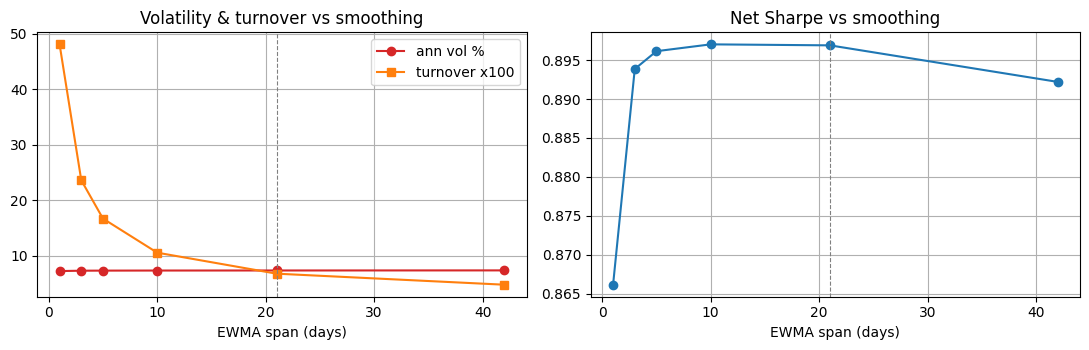

span 1 -> 21:  ann_vol 7.2% -> 7.3%  |  turnover 0.481 -> 0.068  |  Sharpe 0.87 -> 0.90


In [5]:
#| label: fig-smoothing
#| fig-cap: "Effect of EWMA signal smoothing on volatility, turnover and Sharpe"
# How EWMA signal smoothing trades off volatility/turnover vs return (base book).
# span=1 is the raw, unsmoothed signal; larger spans smooth more. We demo on a high-vol
# tree alpha; the chosen SMOOTH_SPAN above is applied to ALL books in the rest of the notebook.
demo = "alpha_tree_raw" if "alpha_tree_raw" in ALPHA_COLS else ALPHA_COLS[0]
SPANS = sorted({1, 3, 5, 10, 21, 42, SMOOTH_SPAN})
rows = {}
for sp in SPANS:
    d = build_book(ap, demo, span=sp)
    rows[sp] = perf(run(*make_matrices(d, "w")), "net")
smooth_tbl = pd.DataFrame(rows).T[["ann_return_%", "ann_vol_%", "Sharpe", "avg_turnover", "maxDD_%"]]
smooth_tbl.index.name = "EWMA_span"
print(f"EWMA signal smoothing on {demo} (base book) — span=1 is raw/unsmoothed:")
display(smooth_tbl.round(3).rename(columns={"Sharpe": "Net Sharpe"}))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(smooth_tbl.index, smooth_tbl["ann_vol_%"], marker="o", color="tab:red", label="ann vol %")
ax[0].plot(smooth_tbl.index, smooth_tbl["avg_turnover"]*100, marker="s", color="tab:orange", label="turnover x100")
ax[0].axvline(SMOOTH_SPAN, color="grey", ls="--", lw=.8); ax[0].set_xlabel("EWMA span (days)")
ax[0].set_title("Volatility & turnover vs smoothing"); ax[0].legend()
ax[1].plot(smooth_tbl.index, smooth_tbl["Sharpe"], marker="o", color="tab:blue")
ax[1].axvline(SMOOTH_SPAN, color="grey", ls="--", lw=.8); ax[1].set_xlabel("EWMA span (days)")
ax[1].set_title("Net Sharpe vs smoothing"); plt.tight_layout(); plt.show()

print(f"span 1 -> {SMOOTH_SPAN}:  ann_vol {smooth_tbl.loc[1,'ann_vol_%']:.1f}% -> {smooth_tbl.loc[SMOOTH_SPAN,'ann_vol_%']:.1f}%"
      f"  |  turnover {smooth_tbl.loc[1,'avg_turnover']:.3f} -> {smooth_tbl.loc[SMOOTH_SPAN,'avg_turnover']:.3f}"
      f"  |  Sharpe {smooth_tbl.loc[1,'Sharpe']:.2f} -> {smooth_tbl.loc[SMOOTH_SPAN,'Sharpe']:.2f}")

## 4. Backtest every selected model — leaderboard & selection

We run all four selected model alphas (raw/idio × regression/tree), each in **base** and **risk-factor-neutral**
form, through the identical engine. Forecast quality is ranked by **information coefficient (IC)** — the
mean daily cross-sectional Spearman rank correlation between the forecast and the realized forward return,
the *same objective the alpha models are selected on* in `alpha_model.ipynb` (not MSE/R²). **Net Sharpe**
(after 1 bp cost, weekly rebalance, ~1-month EWMA-smoothed alpha) is shown alongside as the tradable read.
We therefore display the board twice: ranked by IC (alpha objective) and by net Sharpe (the costed P&L).

In [6]:
#| label: tbl-leaderboard
#| tbl-cap: "Leaderboard of all books (base and risk-factor-neutral)"
# Backtest every final model alpha (base + risk-factor-neutral) on the same engine, then rank.
# OBJECTIVE = INFORMATION COEFFICIENT (IC): mean daily cross-sectional Spearman rank correlation
# between the forecast and realized ret1d_fwd -- the same objective the models are selected on in
# alpha_model.ipynb. Net Sharpe (cost-aware) is reported alongside as the tradable read.
REBAL_LABEL = {1: "daily", 5: "weekly", 21: "monthly"}.get(REBAL_K, f"{REBAL_K}-day")

def alpha_ic(frame, acol):
    """Mean daily cross-sectional Spearman rank IC of a forecast vs realized ret1d_fwd (OOS)."""
    s = frame[["data_date", acol, "ret1d_fwd"]].dropna()
    ic = s.groupby("data_date").apply(lambda x: x[acol].corr(x["ret1d_fwd"], method="spearman"))
    return float(ic.mean())

# IC is a property of the forecast, identical for the base and rf-neutral books of a given alpha.
ic_by_alpha = {acol: alpha_ic(ap, acol) for acol in ALPHA_COLS}

books, results, curves = {}, {}, {}
for acol in ALPHA_COLS:
    d = build_book(ap, acol); books[acol] = d
    for variant, wcol in [("base", "w"), ("rf-neutral", "w_neutral")]:
        W_, R_ = make_matrices(d, wcol)
        b = rebalance_every(W_, R_, REBAL_K)             # <- weekly rebalance
        tag = f"{acol.replace('alpha_','')} [{variant}]"
        stats = perf(b, "net")
        stats["IC"] = ic_by_alpha[acol]                  # forecast-quality objective
        results[tag] = stats
        curves[tag]  = b.net.cumsum() * 100

board = pd.DataFrame(results).T
cols = ["IC", "Sharpe", "ann_return_%", "ann_vol_%", "maxDD_%", "avg_turnover", "ann_cost_%"]
board = board[[c for c in cols if c in board.columns]]

print(f"All models — IC (forecast quality) + net Sharpe of {COST_BPS:g}bp, {REBAL_LABEL} rebalance, full OOS (2011-2017):")
print("\nRanked by IC  (the alpha objective):")
display(board.sort_values("IC", ascending=False).round(4).rename(columns={"Sharpe": "Net Sharpe"}))
print("Ranked by net Sharpe  (the tradable, cost-aware read):")
display(board.sort_values("Sharpe", ascending=False).round(4).rename(columns={"Sharpe": "Net Sharpe"}))

board = board.sort_values("Sharpe", ascending=False)

All models — IC (forecast quality) + net Sharpe of 1bp, weekly rebalance, full OOS (2011-2017):

Ranked by IC  (the alpha objective):


,IC,Net Sharpe,ann_return_%,ann_vol_%,maxDD_%,avg_turnover,ann_cost_%
ens [base],0.0098,0.3605,3.964,11,-27.61,0.053,0.1335
ens [rf-neutral],0.0098,1.413,4.83,3.419,-4.403,0.0735,0.1851
comp [base],0.0097,0.919,6.646,7.231,-12.66,0.0479,0.1207
comp [rf-neutral],0.0097,1.335,4.56,3.416,-4.686,0.058,0.1463
ridge [base],0.0081,0.0398,0.5604,14.07,-40.59,0.059,0.1486
ridge [rf-neutral],0.0081,1.264,4.534,3.587,-4.146,0.1266,0.3191


Ranked by net Sharpe  (the tradable, cost-aware read):


,IC,Net Sharpe,ann_return_%,ann_vol_%,maxDD_%,avg_turnover,ann_cost_%
ens [rf-neutral],0.0098,1.413,4.83,3.419,-4.403,0.0735,0.1851
comp [rf-neutral],0.0097,1.335,4.56,3.416,-4.686,0.058,0.1463
ridge [rf-neutral],0.0081,1.264,4.534,3.587,-4.146,0.1266,0.3191
comp [base],0.0097,0.919,6.646,7.231,-12.66,0.0479,0.1207
ens [base],0.0098,0.3605,3.964,11,-27.61,0.053,0.1335
ridge [base],0.0081,0.0398,0.5604,14.07,-40.59,0.059,0.1486


In [7]:
#| label: out-final-select
# FINAL MODEL: select the one with the highest net Sharpe (cost-aware) 
# `board` is sorted by net Sharpe at the end of §4, so its top row IS the final model. Auto-selected
# (NOT hardcoded) so the deep-dive always follows whatever ranks first after a re-run.
FINAL_TAG = board.index[0]
_name, FINAL_VARIANT = FINAL_TAG.replace("]", "").split(" [")   # e.g. "ens", "rf-neutral"
FINAL_ALPHA = "alpha_" + _name
FINAL_WCOL  = "w_neutral" if FINAL_VARIANT == "rf-neutral" else "w"   # carry the WINNING variant's weights
print(f"Final model selected for deep-dive ({REBAL_LABEL} rebalance): {FINAL_TAG}  ->  {FINAL_ALPHA} [{FINAL_WCOL}]")

df = books[FINAL_ALPHA]                                   # per-name-day book of the best alpha
W, R = make_matrices(df, FINAL_WCOL)                     # the SELECTED variant's weights -> used by §5,7,8,9
bt   = rebalance_every(W, R, REBAL_K)                    # the final model book (selected variant)
oos  = bt[bt.index > pd.to_datetime(str(TRAIN_END), format="%Y%m%d")]

Final model selected for deep-dive (weekly rebalance): ens [rf-neutral]  ->  alpha_ens [w_neutral]


## 5. Performance charts

Charts below are for the **final model book** selected above — its winning variant (base or rf-neutral,
whichever ranked top), net of 1 bp, at the **weekly** rebalance cadence (§4). §8 explores other intervals.

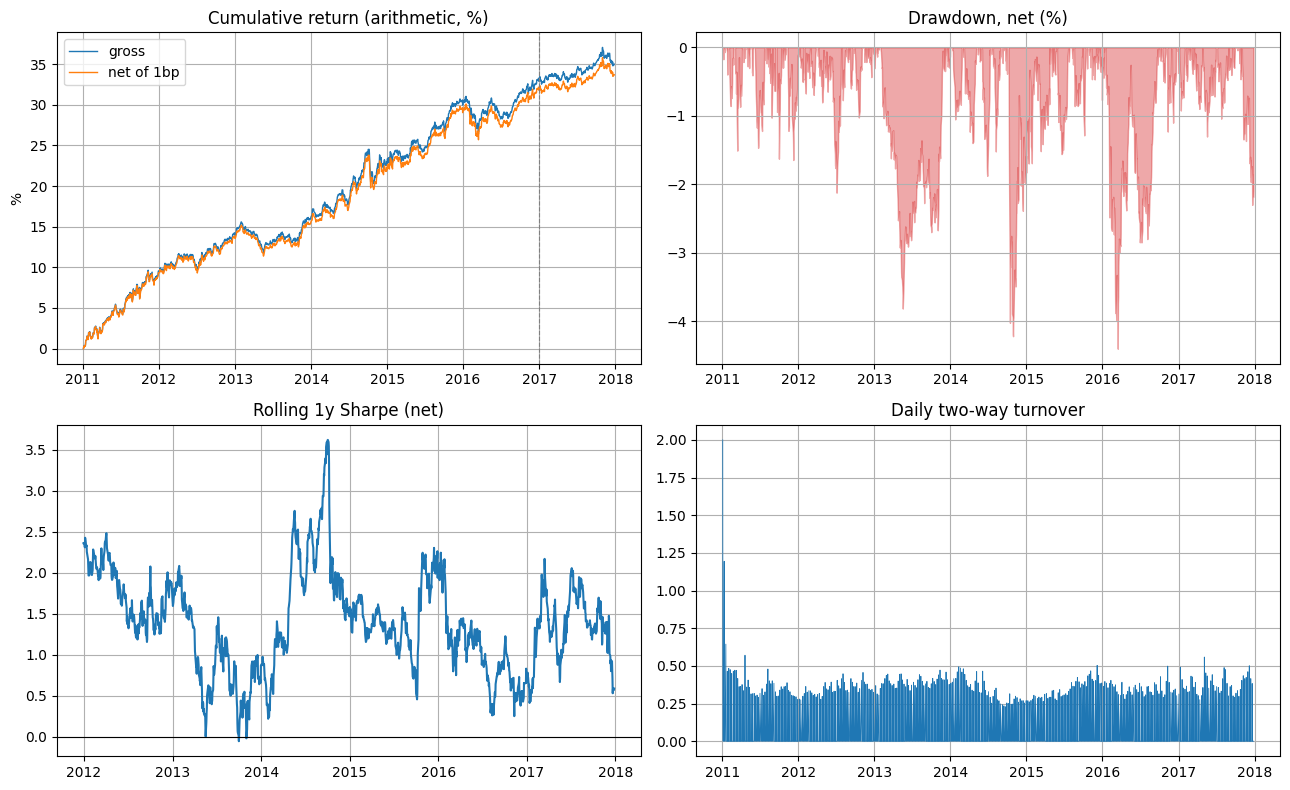

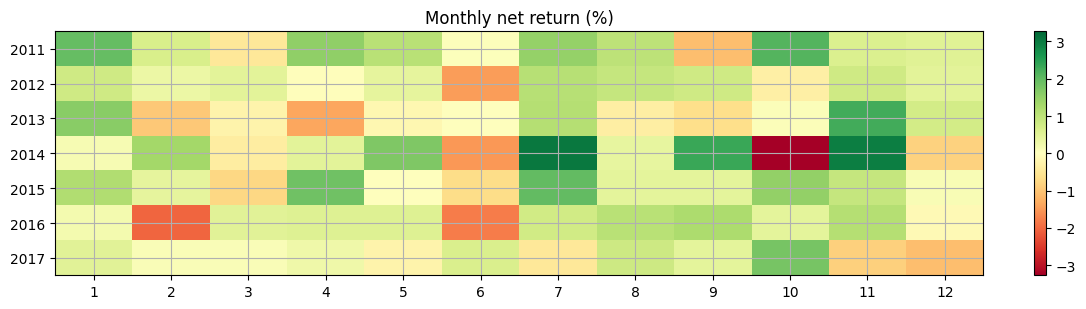

In [8]:
#| label: fig-performance
#| fig-cap: "Final model: cumulative return, drawdown, rolling 1y Sharpe, turnover"
fig, ax = plt.subplots(2, 2, figsize=(13, 8))
# cumulative return (gross vs net)
ax[0,0].plot(bt.index, bt.gross.cumsum()*100, label="gross", lw=1)
ax[0,0].plot(bt.index, bt.net.cumsum()*100, label="net of 1bp", lw=1)
ax[0,0].axvline(pd.to_datetime(str(TRAIN_END), format="%Y%m%d"), color="grey", ls="--", lw=.8)
ax[0,0].set_title("Cumulative return (arithmetic, %)"); ax[0,0].set_ylabel("%"); ax[0,0].legend()
# underwater drawdown (net)
cum = bt.net.cumsum(); dd = (cum - cum.cummax())*100
ax[0,1].fill_between(dd.index, dd.values, 0, color="tab:red", alpha=.4)
ax[0,1].set_title("Drawdown, net (%)")
# rolling 1y Sharpe (net)
roll = bt.net.rolling(252)
ax[1,0].plot(bt.index, (roll.mean()/roll.std()*np.sqrt(252)).values)
ax[1,0].axhline(0, color="k", lw=.8); ax[1,0].set_title("Rolling 1y Sharpe (net)")
# turnover over time
ax[1,1].plot(bt.index, bt.turnover.values, lw=.6)
ax[1,1].set_title("Daily two-way turnover"); 
plt.tight_layout(); plt.show()

# monthly net return heatmap (year x month)
m = bt.net.copy(); m.index = bt.index
mm = m.groupby([m.index.year, m.index.month]).sum().unstack()*100
fig, ax = plt.subplots(figsize=(11, 3.2))
im = ax.imshow(mm.values, cmap="RdYlGn", aspect="auto",
               vmin=-np.nanmax(np.abs(mm.values)), vmax=np.nanmax(np.abs(mm.values)))
ax.set_xticks(range(mm.shape[1])); ax.set_xticklabels(mm.columns)
ax.set_yticks(range(mm.shape[0])); ax.set_yticklabels(mm.index)
ax.set_title("Monthly net return (%)"); fig.colorbar(im, fraction=.025); plt.tight_layout(); plt.show()

## 6. Does risk-factor neutralisation help?

We compare the final model's base book to its risk-factor-neutral variant. Neutralising removes factor-driven
PnL, which usually trades a little raw return for steadier, lower-drawdown performance — useful if the goal
is a clean, high-Sharpe, low-drawdown profile.

Final model ens — base vs rf-neutral, weekly rebalance  (selected variant: rf-neutral)


,ann_return_%,ann_vol_%,Net Sharpe,maxDD_%,maxDD_len_days,pct_pos_days,avg_turnover,ann_cost_%
base (net),3.964,11,0.36,-27.61,492,51.85,0.053,0.133
rf-neutral (net),4.83,3.419,1.413,-4.403,175,55.32,0.073,0.185


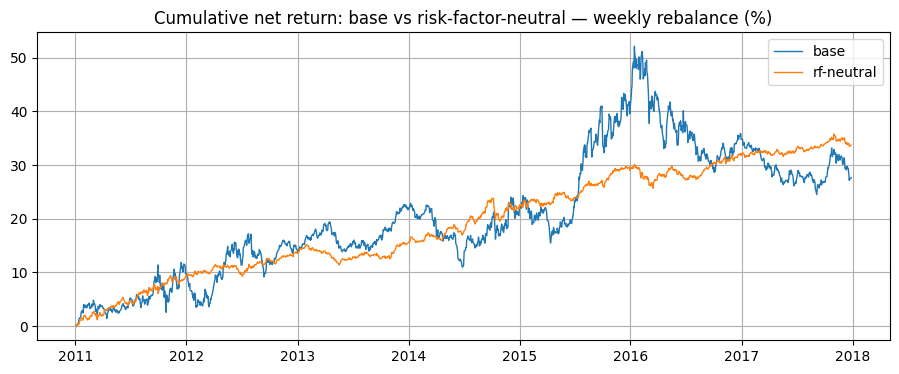

In [9]:
#| label: fig-base-vs-neutral
#| fig-cap: "Base vs risk-factor-neutral cumulative net return"
# Final model alpha: base vs risk-factor-neutral, both at the weekly cadence (independent of which won).
Wb, Rb = make_matrices(df, "w");          bt_base = rebalance_every(Wb, Rb, REBAL_K)
Wn, Rn = make_matrices(df, "w_neutral");  bt_neut = rebalance_every(Wn, Rn, REBAL_K)
cmp = pd.DataFrame({"base (net)": perf(bt_base, "net"), "rf-neutral (net)": perf(bt_neut, "net")}).T
print(f"Final model {_name} — base vs rf-neutral, {REBAL_LABEL} rebalance  (selected variant: {FINAL_VARIANT})")
display(cmp.round(3).rename(columns={"Sharpe": "Net Sharpe"}))
fig, ax = plt.subplots()
ax.plot(bt_base.index, bt_base.net.cumsum()*100, label="base", lw=1)
ax.plot(bt_neut.index, bt_neut.net.cumsum()*100, label="rf-neutral", lw=1)
ax.set_title(f"Cumulative net return: base vs risk-factor-neutral — {REBAL_LABEL} rebalance (%)")
ax.legend(); plt.show()

## 7. Impact of trading cost

The cost only scales turnover, so we can sweep the bp rate against the *same* gross/turnover series.
We show how Sharpe and annual return decay as the assumed cost rises, and the breakeven cost at which
the net Sharpe hits zero — a measure of how much cost headroom the strategy has.

,Net Sharpe,ann_return_pct
cost_bps,,
0,1.467,5.015
0.5,1.44,4.923
1,1.413,4.83
2,1.358,4.645
3,1.304,4.46
5,1.195,4.09
7.5,1.059,3.627
10,0.923,3.164


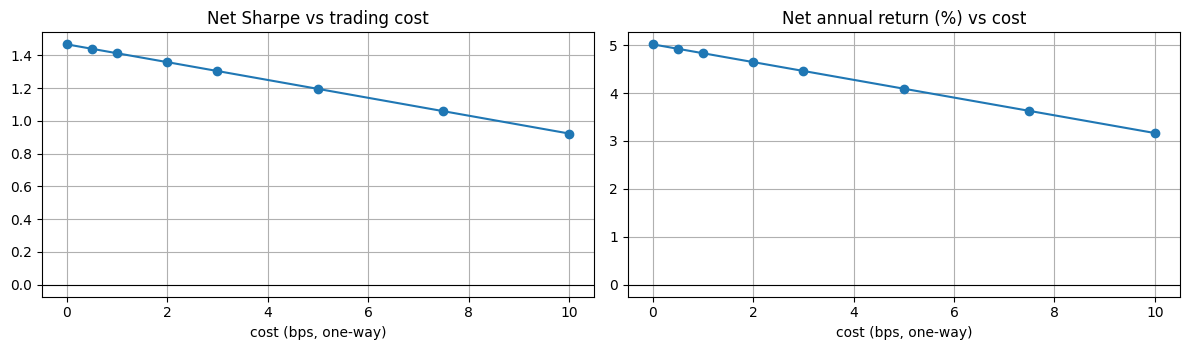

avg daily turnover: 0.07  ->  each 1bp of cost ~= 0.19% / year of return


In [10]:
#| label: fig-cost
#| fig-cap: "Impact of trading cost on net Sharpe and annual return"
rates = [0, 0.5, 1, 2, 3, 5, 7.5, 10]
rows = []
for c in rates:
    net = bt.gross - c*1e-4*bt.turnover
    r = pd.DataFrame({"net":net, "turnover":bt.turnover, "cost":c*1e-4*bt.turnover})
    p = perf(r, "net"); rows.append(dict(cost_bps=c, Sharpe=p["Sharpe"], ann_return_pct=p["ann_return_%"]))
costtbl = pd.DataFrame(rows).set_index("cost_bps")
display(costtbl.round(3).rename(columns={"Sharpe": "Net Sharpe"}))
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].plot(costtbl.index, costtbl.Sharpe, marker="o"); ax[0].axhline(0, color="k", lw=.8)
ax[0].set_xlabel("cost (bps, one-way)"); ax[0].set_title("Net Sharpe vs trading cost")
ax[1].plot(costtbl.index, costtbl.ann_return_pct, marker="o"); ax[1].axhline(0, color="k", lw=.8)
ax[1].set_xlabel("cost (bps, one-way)"); ax[1].set_title("Net annual return (%) vs cost")
plt.tight_layout(); plt.show()
print(f"avg daily turnover: {bt.turnover.mean():.2f}  ->  each 1bp of cost ~= "
      f"{bt.turnover.mean()*1e-4*252*100:.2f}% / year of return")

## 8. Impact of rebalance frequency & turnover control

Two standard levers to cut cost:

1. **Rebalance less often** — refresh target weights every `k` days and hold them in between. Fewer
   rebalances mean less turnover/cost, but the alpha goes stale, so gross return fades. We trace the
   net-Sharpe trade-off across `k`.
2. **Partial rebalancing** — each day move only a fraction `θ` of the way from current to target
   weights (`θ=1` is full daily rebalance). This smooths trading and cuts turnover while keeping the
   book continuously aligned to the latest alpha.

Rebalance every k days (final model weights):


,Net Sharpe,ann_return_pct,avg_turnover,ann_cost_pct
rebalance_k,,,,
1,1.352,4.639,0.152,0.382
2,1.331,4.555,0.108,0.273
3,1.36,4.659,0.091,0.228
5,1.413,4.83,0.073,0.185
10,1.409,4.796,0.055,0.139
21,1.291,4.405,0.039,0.099


Partial rebalancing (fraction toward target):


,Net Sharpe,ann_return_pct,avg_turnover,ann_cost_pct
theta,,,,
1,1.352,4.639,0.152,0.382
0.5,1.379,4.702,0.091,0.228
0.3,1.387,4.711,0.069,0.173
0.2,1.38,4.669,0.056,0.142
0.1,1.337,4.469,0.041,0.102


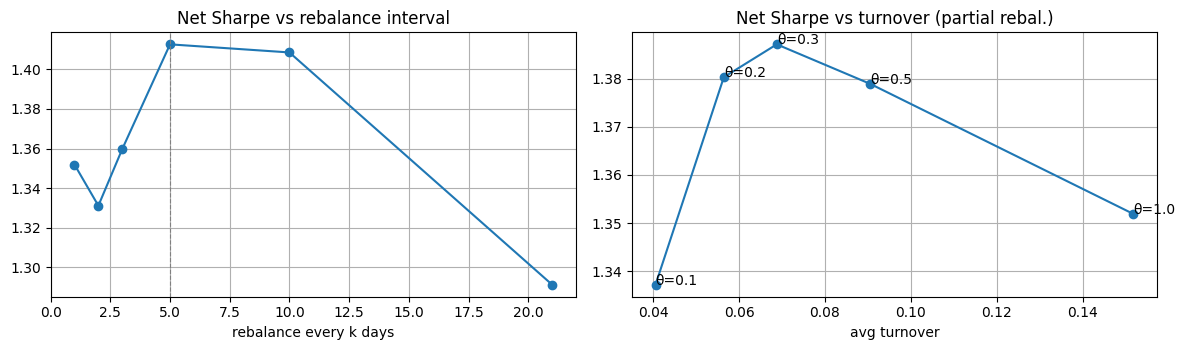

In [11]:
#| label: fig-rebalance
#| fig-cap: "Rebalance frequency and partial-rebalancing trade-offs"
# rebalance_every is defined with the engine (section 2). partial_rebalance is the smoother variant.
def partial_rebalance(W, R, theta):
    Wv = W.values; held = np.zeros(Wv.shape[1]); out = np.empty_like(Wv)
    for t in range(len(Wv)):
        held = held + theta*(Wv[t] - held); out[t] = held
    return run(pd.DataFrame(out, index=W.index, columns=W.columns), R)

freq_rows = []
for k in [1, 2, 3, 5, 10, 21]:
    p = perf(rebalance_every(W, R, k), "net")
    freq_rows.append(dict(rebalance_k=k, Sharpe=p["Sharpe"], ann_return_pct=p["ann_return_%"],
                          avg_turnover=p["avg_turnover"], ann_cost_pct=p["ann_cost_%"]))
freqtbl = pd.DataFrame(freq_rows).set_index("rebalance_k")
print("Rebalance every k days (final model weights):"); display(freqtbl.round(3).rename(columns={"Sharpe": "Net Sharpe"}))

theta_rows = []
for th in [1.0, 0.5, 0.3, 0.2, 0.1]:
    p = perf(partial_rebalance(W, R, th), "net")
    theta_rows.append(dict(theta=th, Sharpe=p["Sharpe"], ann_return_pct=p["ann_return_%"],
                           avg_turnover=p["avg_turnover"], ann_cost_pct=p["ann_cost_%"]))
thetatbl = pd.DataFrame(theta_rows).set_index("theta")
print("Partial rebalancing (fraction toward target):"); display(thetatbl.round(3).rename(columns={"Sharpe": "Net Sharpe"}))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].plot(freqtbl.index, freqtbl.Sharpe, marker="o"); ax[0].set_xlabel("rebalance every k days")
ax[0].axvline(REBAL_K, color="grey", ls="--", lw=.8)        # the cadence used for selection
ax[0].set_title("Net Sharpe vs rebalance interval")
ax[1].plot(thetatbl.avg_turnover, thetatbl.Sharpe, marker="o")
for th,row in thetatbl.iterrows(): ax[1].annotate(f"θ={th}", (row.avg_turnover, row.Sharpe))
ax[1].set_xlabel("avg turnover"); ax[1].set_title("Net Sharpe vs turnover (partial rebal.)")
plt.tight_layout(); plt.show()

### 8.1 Daily vs weekly vs monthly rebalance

A focused comparison at the three cadences you'd actually trade — **daily** (k=1), **weekly** (k=5),
**monthly** (k=21 trading days) — of **net Sharpe** and **average daily two-way turnover** for the
final model book. Rebalancing less often cuts turnover (and therefore cost) but lets the alpha go stale, so
Sharpe usually fades — this isolates that trade-off at the standard frequencies.

Final model book: ens [rf-neutral] — net of 1bp, daily/weekly/monthly rebalance


,k_days,Net Sharpe,ann_return_pct,avg_turnover,ann_cost_pct
rebalance,,,,,
daily,1,1.352,4.639,0.152,0.382
weekly,5,1.413,4.83,0.073,0.185
monthly,21,1.291,4.405,0.039,0.099


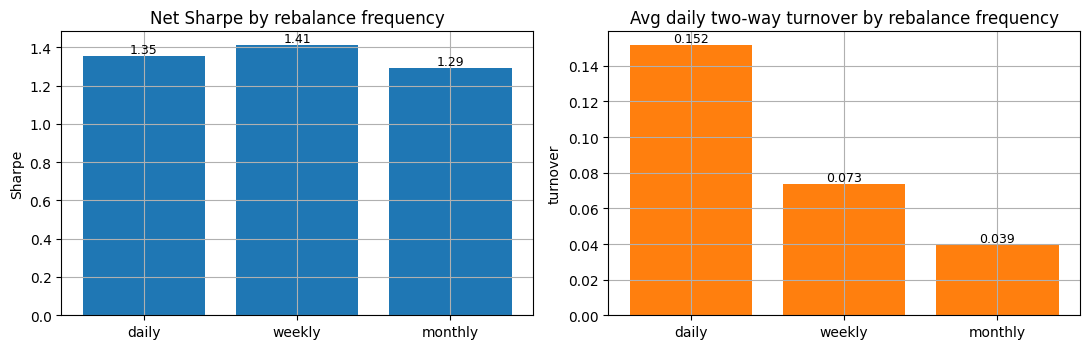

Highest net Sharpe: weekly (1.41)  |  turnover daily->monthly: 0.152 -> 0.039


In [12]:
#| label: fig-rebalance-freq
#| fig-cap: "Net Sharpe and turnover by rebalance frequency"
# Daily vs weekly vs monthly rebalance — Sharpe & turnover for the final model book.
# Reuse rebalance_every (above): refresh target weights every k trading days, hold in between.
FREQS = {"daily": 1, "weekly": 5, "monthly": 21}        # ~5 trading days / week, ~21 / month
rows = []
for label, k in FREQS.items():
    p = perf(rebalance_every(W, R, k), "net")
    rows.append(dict(rebalance=label, k_days=k, Sharpe=p["Sharpe"],
                     ann_return_pct=p["ann_return_%"], avg_turnover=p["avg_turnover"],
                     ann_cost_pct=p["ann_cost_%"]))
rebal_freq = pd.DataFrame(rows).set_index("rebalance")
print(f"Final model book: {FINAL_TAG} — net of {COST_BPS:g}bp, daily/weekly/monthly rebalance")
display(rebal_freq.round(3).rename(columns={"Sharpe": "Net Sharpe"}))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].bar(rebal_freq.index, rebal_freq["Sharpe"], color="tab:blue")
ax[0].set_title("Net Sharpe by rebalance frequency"); ax[0].set_ylabel("Sharpe")
for i, v in enumerate(rebal_freq["Sharpe"]):
    ax[0].text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
ax[1].bar(rebal_freq.index, rebal_freq["avg_turnover"], color="tab:orange")
ax[1].set_title("Avg daily two-way turnover by rebalance frequency"); ax[1].set_ylabel("turnover")
for i, v in enumerate(rebal_freq["avg_turnover"]):
    ax[1].text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

best = rebal_freq["Sharpe"].idxmax()
print(f"Highest net Sharpe: {best} ({rebal_freq.loc[best,'Sharpe']:.2f})  |  "
      f"turnover daily->monthly: {rebal_freq.loc['daily','avg_turnover']:.3f} -> "
      f"{rebal_freq.loc['monthly','avg_turnover']:.3f}")

## 9. Summary

Headline statistics of the final model book (**weekly** rebalance, 1 bp cost) plus the full leaderboard, as
needed for the report. The entire curve is walk-forward OOS (rolling 12-month train, monthly retrain).

FINAL MODEL:  ens [rf-neutral]
net of 1bp · weekly rebalance · walk-forward OOS (rolling 12m train, monthly retrain)


,Full OOS (2011–2017),Since 2016-12-31
Annualised return,4.83%,1.94%
Annualised volatility,3.42%,2.88%
Net Sharpe,1.41,0.67
Max drawdown,-4.40%,-2.30%
Max drawdown length,175 days,38 days
Positive days,55.3%,56.2%
Avg daily turnover,0.073,0.076
Annual cost drag,0.19%,0.19%


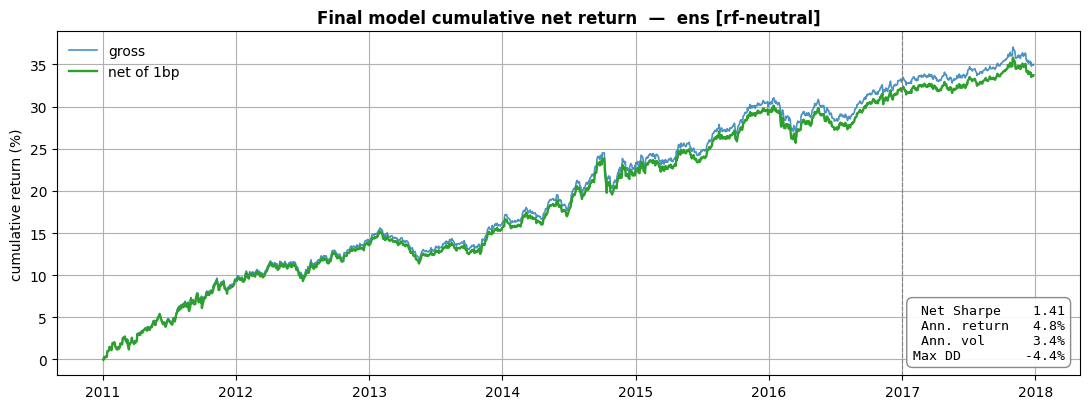


Leaderboard — all models, net of 1bp, weekly rebalance (final model highlighted):


,IC,Net Sharpe,Ann.return %,Ann.vol %,MaxDD %,Turnover,Cost %/yr
ens [rf-neutral],0.0098,1.41,4.83,3.42,-4.40,0.073,0.19
comp [rf-neutral],0.0097,1.33,4.56,3.42,-4.69,0.058,0.15
ridge [rf-neutral],0.0081,1.26,4.53,3.59,-4.15,0.127,0.32
comp [base],0.0097,0.92,6.65,7.23,-12.66,0.048,0.12
ens [base],0.0098,0.36,3.96,11.00,-27.61,0.053,0.13
ridge [base],0.0081,0.04,0.56,14.07,-40.59,0.059,0.15



Notes for the report:
  • Walk-forward OOS (rolling 12m train, monthly retrain, 2011–2017); ~1m EWMA-smoothed alpha.
  • Models selected by IC upstream; models compared & selected here at weekly rebalance (k=5).
  • Dollar-neutral by construction (net exposure ~0, gross ~2).
  • base vs rf-neutral in §6; cost headroom in §7; rebalance/turnover in §8.


In [13]:
#| label: fig-tearsheet
#| fig-cap: "Final model headline cumulative net return"
# ============================================================
# 9. Final results — final model tear-sheet + leaderboard (formatted for the report)
# ============================================================
full_stats = perf(bt, "net")
oos_stats  = perf(oos, "net")
split_lbl  = pd.to_datetime(str(TRAIN_END), format="%Y%m%d").strftime("%Y-%m-%d")

def _fmt_stats(s):
    return pd.Series({
        "Annualised return":     f"{s['ann_return_%']:.2f}%",
        "Annualised volatility": f"{s['ann_vol_%']:.2f}%",
        "Net Sharpe":            f"{s['Sharpe']:.2f}",
        "Max drawdown":          f"{s['maxDD_%']:.2f}%",
        "Max drawdown length":   f"{s['maxDD_len_days']:.0f} days",
        "Positive days":         f"{s['pct_pos_days']:.1f}%",
        "Avg daily turnover":    f"{s['avg_turnover']:.3f}",
        "Annual cost drag":      f"{s['ann_cost_%']:.2f}%",
    })

headline = pd.DataFrame({
    f"Full OOS ({bt.index.min():%Y}–{bt.index.max():%Y})": _fmt_stats(full_stats),
    f"Since {split_lbl}":                                       _fmt_stats(oos_stats),
})

print("=" * 72)
print(f"FINAL MODEL:  {FINAL_TAG}")
print(f"net of {COST_BPS:g}bp · {REBAL_LABEL} rebalance · walk-forward OOS (rolling 12m train, monthly retrain)")
print("=" * 72)
try:
    display(headline.style
            .set_caption("Headline performance")
            .set_properties(**{"text-align": "right"})
            .set_table_styles([{"selector": "caption",
                                "props": [("font-weight", "bold"), ("font-size", "13px"),
                                          ("text-align", "left"), ("padding-bottom", "6px")]},
                               {"selector": "th.col_heading",
                                "props": [("text-align", "right")]}]))
except NameError:
    print(headline.to_string())

# ---- headline equity curve (gross vs net) with a key-stats box ----
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(bt.index, bt.gross.cumsum() * 100, lw=1.2, color="tab:blue",  alpha=.8, label="gross")
ax.plot(bt.index, bt.net.cumsum()   * 100, lw=1.7, color="tab:green",          label=f"net of {COST_BPS:g}bp")
ax.axvline(pd.to_datetime(str(TRAIN_END), format="%Y%m%d"), color="grey", ls="--", lw=.8)
ax.set_title(f"Final model cumulative net return  —  {FINAL_TAG}", fontsize=12, fontweight="bold")
ax.set_ylabel("cumulative return (%)"); ax.legend(loc="upper left", frameon=False)
box = (f"Net Sharpe    {full_stats['Sharpe']:.2f}\n"
       f"Ann. return   {full_stats['ann_return_%']:.1f}%\n"
       f"Ann. vol      {full_stats['ann_vol_%']:.1f}%\n"
       f"Max DD        {full_stats['maxDD_%']:.1f}%")
ax.text(0.985, 0.04, box, transform=ax.transAxes, ha="right", va="bottom",
        fontsize=9.5, family="monospace",
        bbox=dict(boxstyle="round,pad=0.45", fc="white", ec="grey", alpha=.92))
plt.tight_layout(); plt.show()

# ---- full leaderboard: final model highlighted, gradients on the objective (IC) and the P&L (Sharpe) ----
lb_cols = {"IC": "IC", "Sharpe": "Net Sharpe", "ann_return_%": "Ann.return %", "ann_vol_%": "Ann.vol %",
           "maxDD_%": "MaxDD %", "avg_turnover": "Turnover", "ann_cost_%": "Cost %/yr"}
lb = board.rename(columns=lb_cols)
fmt_map = {"IC": "{:.4f}", "Net Sharpe": "{:.2f}", "Ann.return %": "{:.2f}", "Ann.vol %": "{:.2f}",
           "MaxDD %": "{:.2f}", "Turnover": "{:.3f}", "Cost %/yr": "{:.2f}"}

def _hl_final(row):
    on = row.name == FINAL_TAG
    return ['background-color:#fff3cd; font-weight:bold' if on else '' for _ in row]

print(f"\nLeaderboard — all models, net of {COST_BPS:g}bp, {REBAL_LABEL} rebalance (final model highlighted):")
try:
    display(lb.style
            .format({k: v for k, v in fmt_map.items() if k in lb.columns})
            .background_gradient(subset=[c for c in ["Net Sharpe"] if c in lb.columns], cmap="Greens")
            .background_gradient(subset=[c for c in ["IC"] if c in lb.columns], cmap="Blues")
            .apply(_hl_final, axis=1)
            .set_caption("ranked by net Sharpe (the tradable read);  IC = forecast objective from alpha_model.ipynb"))
except NameError:
    print(lb.round(4).to_string())

print("\nNotes for the report:")
print("  • Walk-forward OOS (rolling 12m train, monthly retrain, 2011–2017); ~1m EWMA-smoothed alpha.")
print(f"  • Models selected by IC upstream; models compared & selected here at {REBAL_LABEL} rebalance (k={REBAL_K}).")
print("  • Dollar-neutral by construction (net exposure ~0, gross ~2).")
print("  • base vs rf-neutral in §6; cost headroom in §7; rebalance/turnover in §8.")

In [14]:
#| label: tbl-oos-only
#| tbl-cap: "Out-of-sample-only performance"
# ---- Out-of-sample-only results: final model book restricted to the post-TRAIN_END window ----
# The whole curve is already walk-forward OOS; this isolates the stricter holdout (after TRAIN_END)
# inside it. `oos` (final model net returns after TRAIN_END) and `perf` are defined above.
oos_perf = perf(oos, "net")
_oos_from = pd.to_datetime(str(TRAIN_END), format="%Y%m%d").strftime("%Y-%m-%d")
oos_tbl = pd.Series({
    "Annualised return":     f"{oos_perf['ann_return_%']:.2f}%",
    "Annualised volatility": f"{oos_perf['ann_vol_%']:.2f}%",
    "Net Sharpe":          f"{oos_perf['Sharpe']:.2f}",
    "Max drawdown":          f"{oos_perf['maxDD_%']:.2f}%",
    "Max drawdown length":   f"{oos_perf['maxDD_len_days']:.0f} days",
    "Positive days":         f"{oos_perf['pct_pos_days']:.1f}%",
    "Avg daily turnover":    f"{oos_perf['avg_turnover']:.3f}",
    "Annual cost drag":      f"{oos_perf['ann_cost_%']:.2f}%",
}, name=f"OOS only  ({oos.index.min():%Y-%m-%d} → {oos.index.max():%Y-%m-%d})")

print(f"FINAL MODEL — OUT-OF-SAMPLE ONLY (after {_oos_from}):  {FINAL_TAG}  ·  net of {COST_BPS:g}bp  ·  {REBAL_LABEL} rebalance")
try:
    display(oos_tbl.to_frame()
            .style.set_caption("Out-of-sample-only performance")
            .set_properties(**{"text-align": "right"})
            .set_table_styles([{"selector": "caption",
                                "props": [("font-weight", "bold"), ("font-size", "13px"),
                                          ("text-align", "left"), ("padding-bottom", "6px")]}]))
except NameError:
    print(oos_tbl.to_string())

FINAL MODEL — OUT-OF-SAMPLE ONLY (after 2016-12-31):  ens [rf-neutral]  ·  net of 1bp  ·  weekly rebalance


,OOS only (2017-01-03 → 2017-12-27)
Annualised return,1.94%
Annualised volatility,2.88%
Net Sharpe,0.67
Max drawdown,-2.30%
Max drawdown length,38 days
Positive days,56.2%
Avg daily turnover,0.076
Annual cost drag,0.19%
